   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...           0.00          0.0

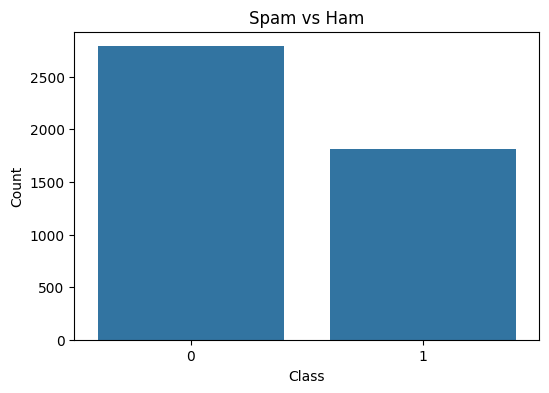

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

df = pd.read_csv("spambase_csv.csv")

print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")

print(df.isnull().sum())

print("\nStatistical Summary")

print(df.describe())

plt.figure(figsize=(6,4))

sns.countplot(x=df["class"])

plt.title("Spam vs Ham")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

X = df.drop("class", axis=1)

y = df["class"]

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


Baseline Logistic Regression
Accuracy : 0.9294245385450597
Precision: 0.9209039548022598
Recall   : 0.8980716253443526
F1 Score : 0.9093444909344491
Training Time: 0.041961669921875

Grid Search - Logistic Regression
Best Parameters
{'C': 1, 'penalty': 'l1', 'solver': 'saga'}

Best Cross Validation Accuracy
0.9239130434782608

Training Time
581.0236709117889

Tuned Logistic Regression
Accuracy : 0.9294245385450597
Precision: 0.9209039548022598
Recall   : 0.8980716253443526
F1 Score : 0.9093444909344491


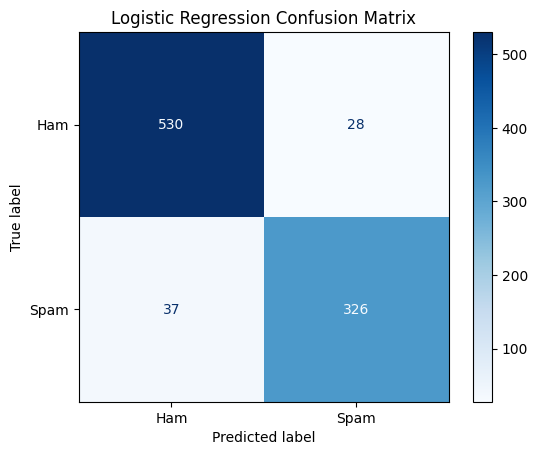

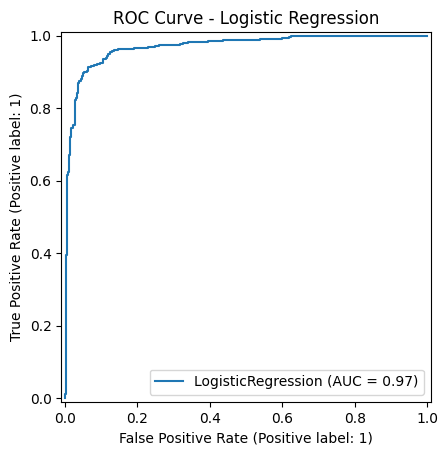


Logistic Regression Performance
              Metric     Value
0           Accuracy  0.929425
1          Precision  0.920904
2             Recall  0.898072
3           F1 Score  0.909344
4  Training Time (s)  0.041962


In [ ]:
print("\n========================================")
print("Baseline Logistic Regression")
print("========================================")

start = time.time()

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

end = time.time()

training_time = end - start

prediction = log_model.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

precision = precision_score(y_test, prediction)

recall = recall_score(y_test, prediction)

f1 = f1_score(y_test, prediction)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

print("Training Time:", training_time)

print("\n========================================")
print("Grid Search - Logistic Regression")
print("========================================")

param_grid = {

    "penalty": ["l1", "l2"],

    "C": [0.01, 0.1, 1, 10, 100],

    "solver": ["liblinear", "saga"]

}

grid_log = GridSearchCV(

    LogisticRegression(max_iter=5000),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

start = time.time()

grid_log.fit(X_train, y_train)

end = time.time()

best_log = grid_log.best_estimator_

print("Best Parameters")

print(grid_log.best_params_)

print("\nBest Cross Validation Accuracy")

print(grid_log.best_score_)

print("\nTraining Time")

print(end-start)

prediction = best_log.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

precision = precision_score(y_test, prediction)

recall = recall_score(y_test, prediction)

f1 = f1_score(y_test, prediction)

print("\n========================================")
print("Tuned Logistic Regression")
print("========================================")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

cm = confusion_matrix(

    y_test,

    prediction

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Ham", "Spam"]

)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

RocCurveDisplay.from_estimator(

    best_log,

    X_test,

    y_test

)

plt.title("ROC Curve - Logistic Regression")

plt.show()

logistic_table = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Training Time (s)"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        training_time

    ]

})

print("\n========================================")

print("Logistic Regression Performance")

print("========================================")

print(logistic_table)


Support Vector Machine

Kernel : linear
Accuracy : 0.9305103148751357
Precision: 0.9235127478753541
Recall   : 0.8980716253443526
F1 Score : 0.9106145251396648
Training Time: 2.0093955993652344

Kernel : poly
Accuracy : 0.7795874049945711
Precision: 0.9597701149425287
Recall   : 0.46005509641873277
F1 Score : 0.6219739292364991
Training Time: 1.3041446208953857

Kernel : rbf
Accuracy : 0.9272529858849077
Precision: 0.9277456647398844
Recall   : 0.8842975206611571
F1 Score : 0.9055007052186178
Training Time: 0.6157901287078857

Kernel : sigmoid
Accuracy : 0.8838219326818675
Precision: 0.8535911602209945
Recall   : 0.8512396694214877
F1 Score : 0.8524137931034482
Training Time: 0.7044162750244141

Grid Search - SVM

Best Parameters
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross Validation Accuracy
0.9339673913043478

Training Time
20.678475379943848

Best SVM Performance
Accuracy : 0.9272529858849077
Precision: 0.9277456647398844
Recall   : 0.8842975206611571
F1 Score : 0.90550

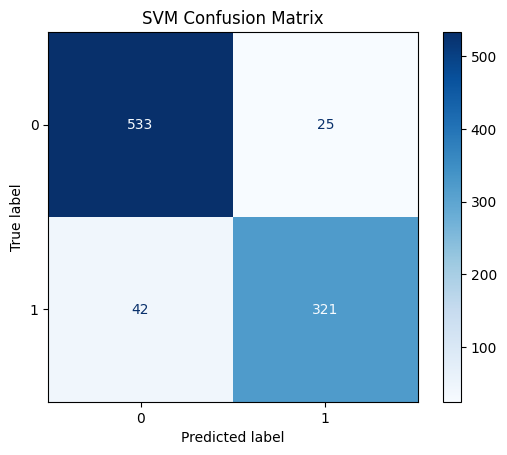

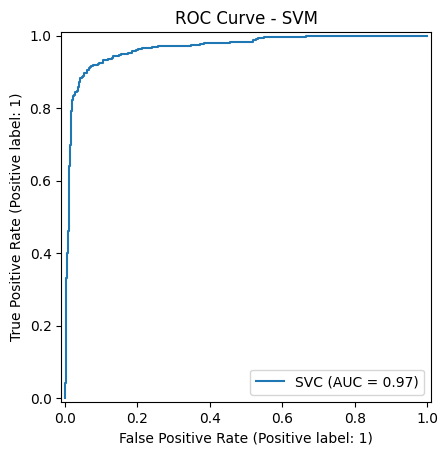


SVM Kernel Performance
    Kernel  Accuracy  Precision    Recall  F1 Score  Training Time (s)
0   linear  0.930510   0.923513  0.898072  0.910615           2.009396
1     poly  0.779587   0.959770  0.460055  0.621974           1.304145
2      rbf  0.927253   0.927746  0.884298  0.905501           0.615790
3  sigmoid  0.883822   0.853591  0.851240  0.852414           0.704416

5-Fold Cross Validation
   Fold  Logistic Regression       SVM
0     1             0.919653  0.932682
1     2             0.928261  0.933696
2     3             0.930435  0.950000
3     4             0.941304  0.948913
4     5             0.833696  0.850000

Average Logistic Accuracy : 0.9106696407496576
Average SVM Accuracy : 0.9230581126374922


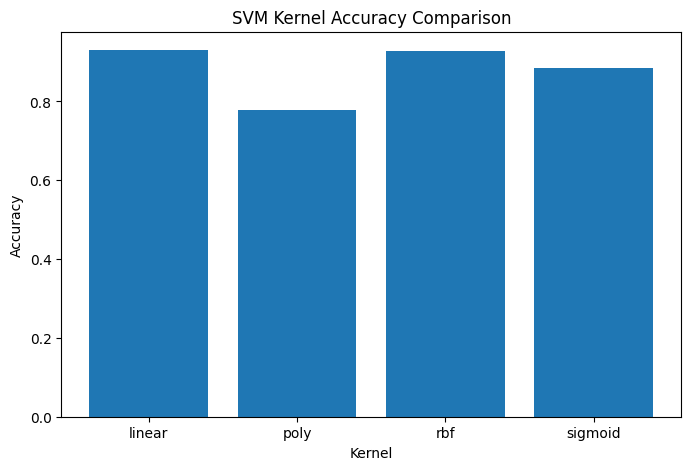


Final Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.929425   0.920904  0.898072  0.909344
1                  SVM  0.927253   0.927746  0.884298  0.905501

Experiment Completed Successfully.


In [ ]:
print("\n========================================")
print("Support Vector Machine")
print("========================================")

kernels = ["linear", "poly", "rbf", "sigmoid"]

svm_results = []

for kernel in kernels:

    print(f"\nKernel : {kernel}")

    svm = SVC(kernel=kernel)

    start = time.time()

    svm.fit(X_train, y_train)

    training_time = time.time() - start

    prediction = svm.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    svm_results.append([
        kernel,
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ])

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("Training Time:", training_time)

print("\n========================================")
print("Grid Search - SVM")
print("========================================")


param_grid = {

    "kernel": ["linear", "rbf"],

    "C": [1, 10],

    "gamma": ["scale"]

}

grid_svm = GridSearchCV(

    estimator=SVC(),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

start = time.time()

grid_svm.fit(X_train, y_train)

training_time = time.time() - start

best_svm = grid_svm.best_estimator_

print("\nBest Parameters")
print(grid_svm.best_params_)

print("\nBest Cross Validation Accuracy")
print(grid_svm.best_score_)

print("\nTraining Time")
print(training_time)

prediction = best_svm.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

precision = precision_score(y_test, prediction)

recall = recall_score(y_test, prediction)

f1 = f1_score(y_test, prediction)

print("\n========================================")
print("Best SVM Performance")
print("========================================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

ConfusionMatrixDisplay.from_estimator(

    best_svm,

    X_test,

    y_test,

    cmap="Blues"

)

plt.title("SVM Confusion Matrix")

plt.show()

RocCurveDisplay.from_estimator(

    best_svm,

    X_test,

    y_test

)

plt.title("ROC Curve - SVM")

plt.show()

svm_table = pd.DataFrame(

    svm_results,

    columns=[

        "Kernel",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Training Time (s)"

    ]

)

print("\nSVM Kernel Performance")

print(svm_table)

print("\n========================================")
print("5-Fold Cross Validation")
print("========================================")

log_cv = cross_val_score(

    best_log,

    X,

    y,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

svm_cv = cross_val_score(

    best_svm,

    X,

    y,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

cv_table = pd.DataFrame({

    "Fold": [1,2,3,4,5],

    "Logistic Regression": log_cv,

    "SVM": svm_cv

})

print(cv_table)

print("\nAverage Logistic Accuracy :", log_cv.mean())

print("Average SVM Accuracy :", svm_cv.mean())

plt.figure(figsize=(8,5))

plt.bar(

    svm_table["Kernel"],

    svm_table["Accuracy"]

)

plt.xlabel("Kernel")

plt.ylabel("Accuracy")

plt.title("SVM Kernel Accuracy Comparison")

plt.show()

comparison = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "SVM"

    ],

    "Accuracy": [

        accuracy_score(y_test, best_log.predict(X_test)),

        accuracy_score(y_test, best_svm.predict(X_test))

    ],

    "Precision": [

        precision_score(y_test, best_log.predict(X_test)),

        precision_score(y_test, best_svm.predict(X_test))

    ],

    "Recall": [

        recall_score(y_test, best_log.predict(X_test)),

        recall_score(y_test, best_svm.predict(X_test))

    ],

    "F1 Score": [

        f1_score(y_test, best_log.predict(X_test)),

        f1_score(y_test, best_svm.predict(X_test))

    ]

})

print("\nFinal Model Comparison")

print(comparison)

print("\nExperiment Completed Successfully.")

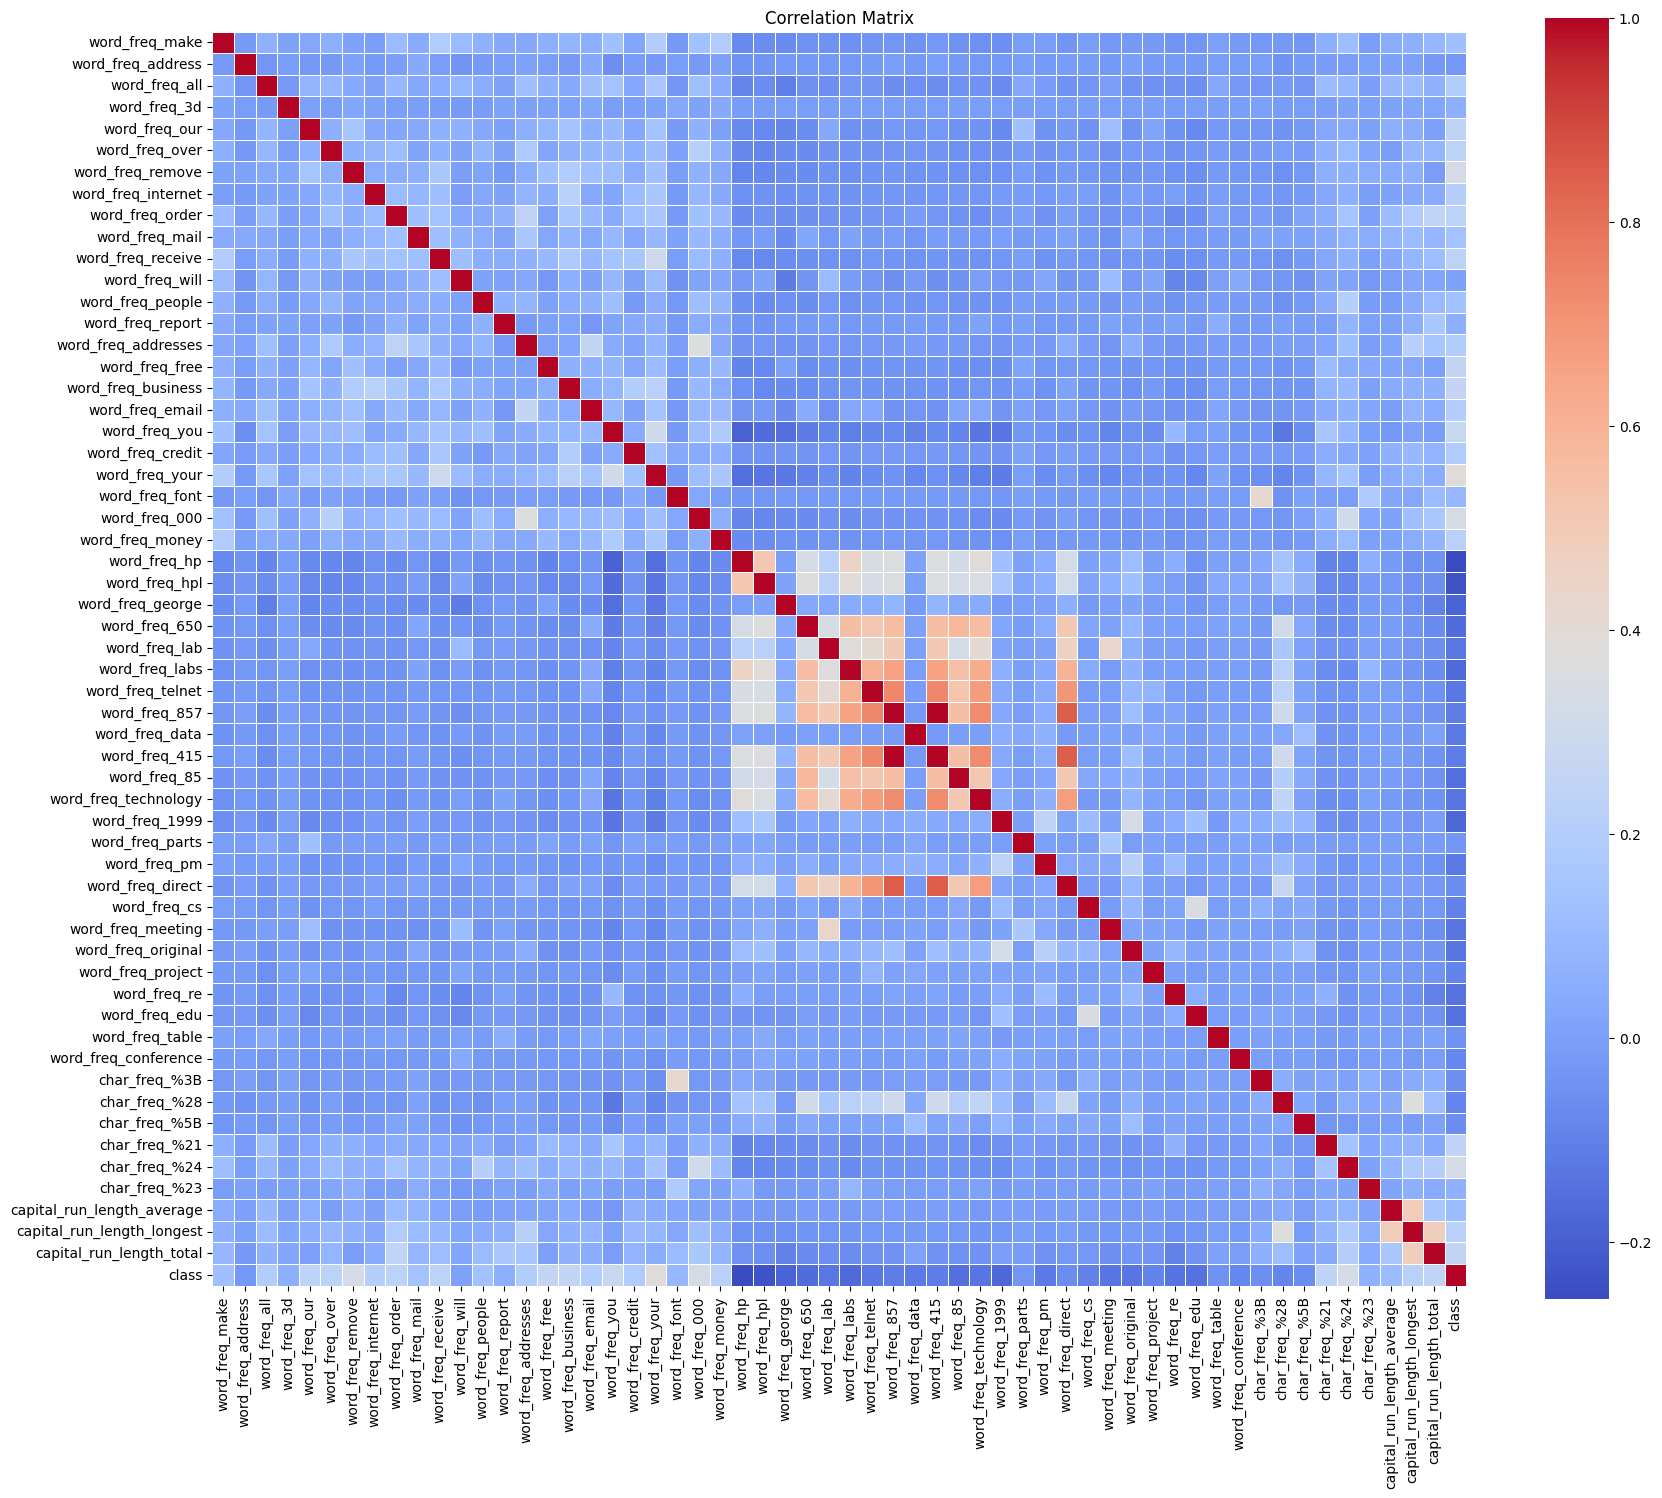

In [ ]:

plt.figure(figsize=(18,15))

corr = df.corr(numeric_only=True)

sns.heatmap(

    corr,

    annot=False,

    cmap="coolwarm",

    square=True,

    linewidths=0.5,

    cbar=True

)

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()